# trend_xchart function demo

In [1]:
# Import libraries
from process_improvement.charts.xmr_charts import trend_xchart
from process_improvement.charts.utils import XmRChartConfig

from process_improvement.data_loader import list_example_files, load_example_data

%matplotlib inline

## Get data

In [2]:
# list example files
list_example_files()

['18650_battery_cells',
 '2170_battery_cell',
 'automated_manufacturing_part_lengths',
 'eight_machine_manufacturing_process',
 'manufacturing_PMI',
 'milikans_electron_charge_observations',
 'monthly_united_states_trade_deficits_2024',
 'OP200_weekly_first_pass_yield',
 'quarterly_sales_by_region',
 'shewharts_resistance_measurements',
 'software_verification_death_to_birth_rates',
 'software_verification_resistance_measurement',
 'wafer_assembly_part_placement']

In [3]:
# Create sales dataframe
sales_df = load_example_data("quarterly_sales_by_region")

sales_df = sales_df.drop(['Unnamed: 7', 'Unnamed: 8'], axis=1)

sales_df.head()

,Quarter,Region A,Region B,Region C,Region D,Region E,Region F
0,1,924,1412,1056,539,397,431
1,2,928,1280,1048,558,391,470
2,3,956,1129,1129,591,414,439
3,4,1222,1181,1073,556,407,431
4,5,748,1149,1157,540,415,471


In [4]:
# Create list of regions
unique_regions = sales_df.columns.drop('Quarter')
unique_regions

Index(['Region A', 'Region B', 'Region C', 'Region D', 'Region E', 'Region F'], dtype='object')

In [5]:
# Melt sales dataframe
sales_melt = sales_df.melt(id_vars='Quarter', 
                           value_vars=unique_regions, 
                           var_name='Region', 
                           value_name='Sales ($)')
sales_melt

,Quarter,Region,Sales ($)
0,1,Region A,924
1,2,Region A,928
2,3,Region A,956
3,4,Region A,1222
4,5,Region A,748
...,...,...,...
115,16,Region F,670
116,17,Region F,588
117,18,Region F,699
118,19,Region F,743


In [15]:
# Create Region B dataframe
region_B = sales_melt[sales_melt['Region'] == 'Region B'].reset_index(drop=True)
region_B

,Quarter,Region,Sales ($)
0,1,Region B,1412
1,2,Region B,1280
2,3,Region B,1129
3,4,Region B,1181
4,5,Region B,1149
5,6,Region B,1248
6,7,Region B,1103
7,8,Region B,1021
8,9,Region B,1085
9,10,Region B,1125


In [16]:
# Create Region D dataframe
region_D = sales_melt[sales_melt['Region'] == 'Region D'].reset_index(drop=True)
region_D

,Quarter,Region,Sales ($)
0,1,Region D,539
1,2,Region D,558
2,3,Region D,591
3,4,Region D,556
4,5,Region D,540
5,6,Region D,590
6,7,Region D,606
7,8,Region D,643
8,9,Region D,657
9,10,Region D,602


In [17]:
# Create Region F dataframe
region_F = sales_melt[sales_melt['Region'] == 'Region F'].reset_index(drop=True)
region_F

,Quarter,Region,Sales ($)
0,1,Region F,431
1,2,Region F,470
2,3,Region F,439
3,4,Region F,431
4,5,Region F,471
5,6,Region F,496
6,7,Region F,506
7,8,Region F,573
8,9,Region F,403
9,10,Region F,440


## XmRChartConfiguartion

In [18]:
# Trend chart uses XmRChartConfig
config = XmRChartConfig(
    tickinterval=1,
    round_value=1
)

## Trended X chart for Region B sales

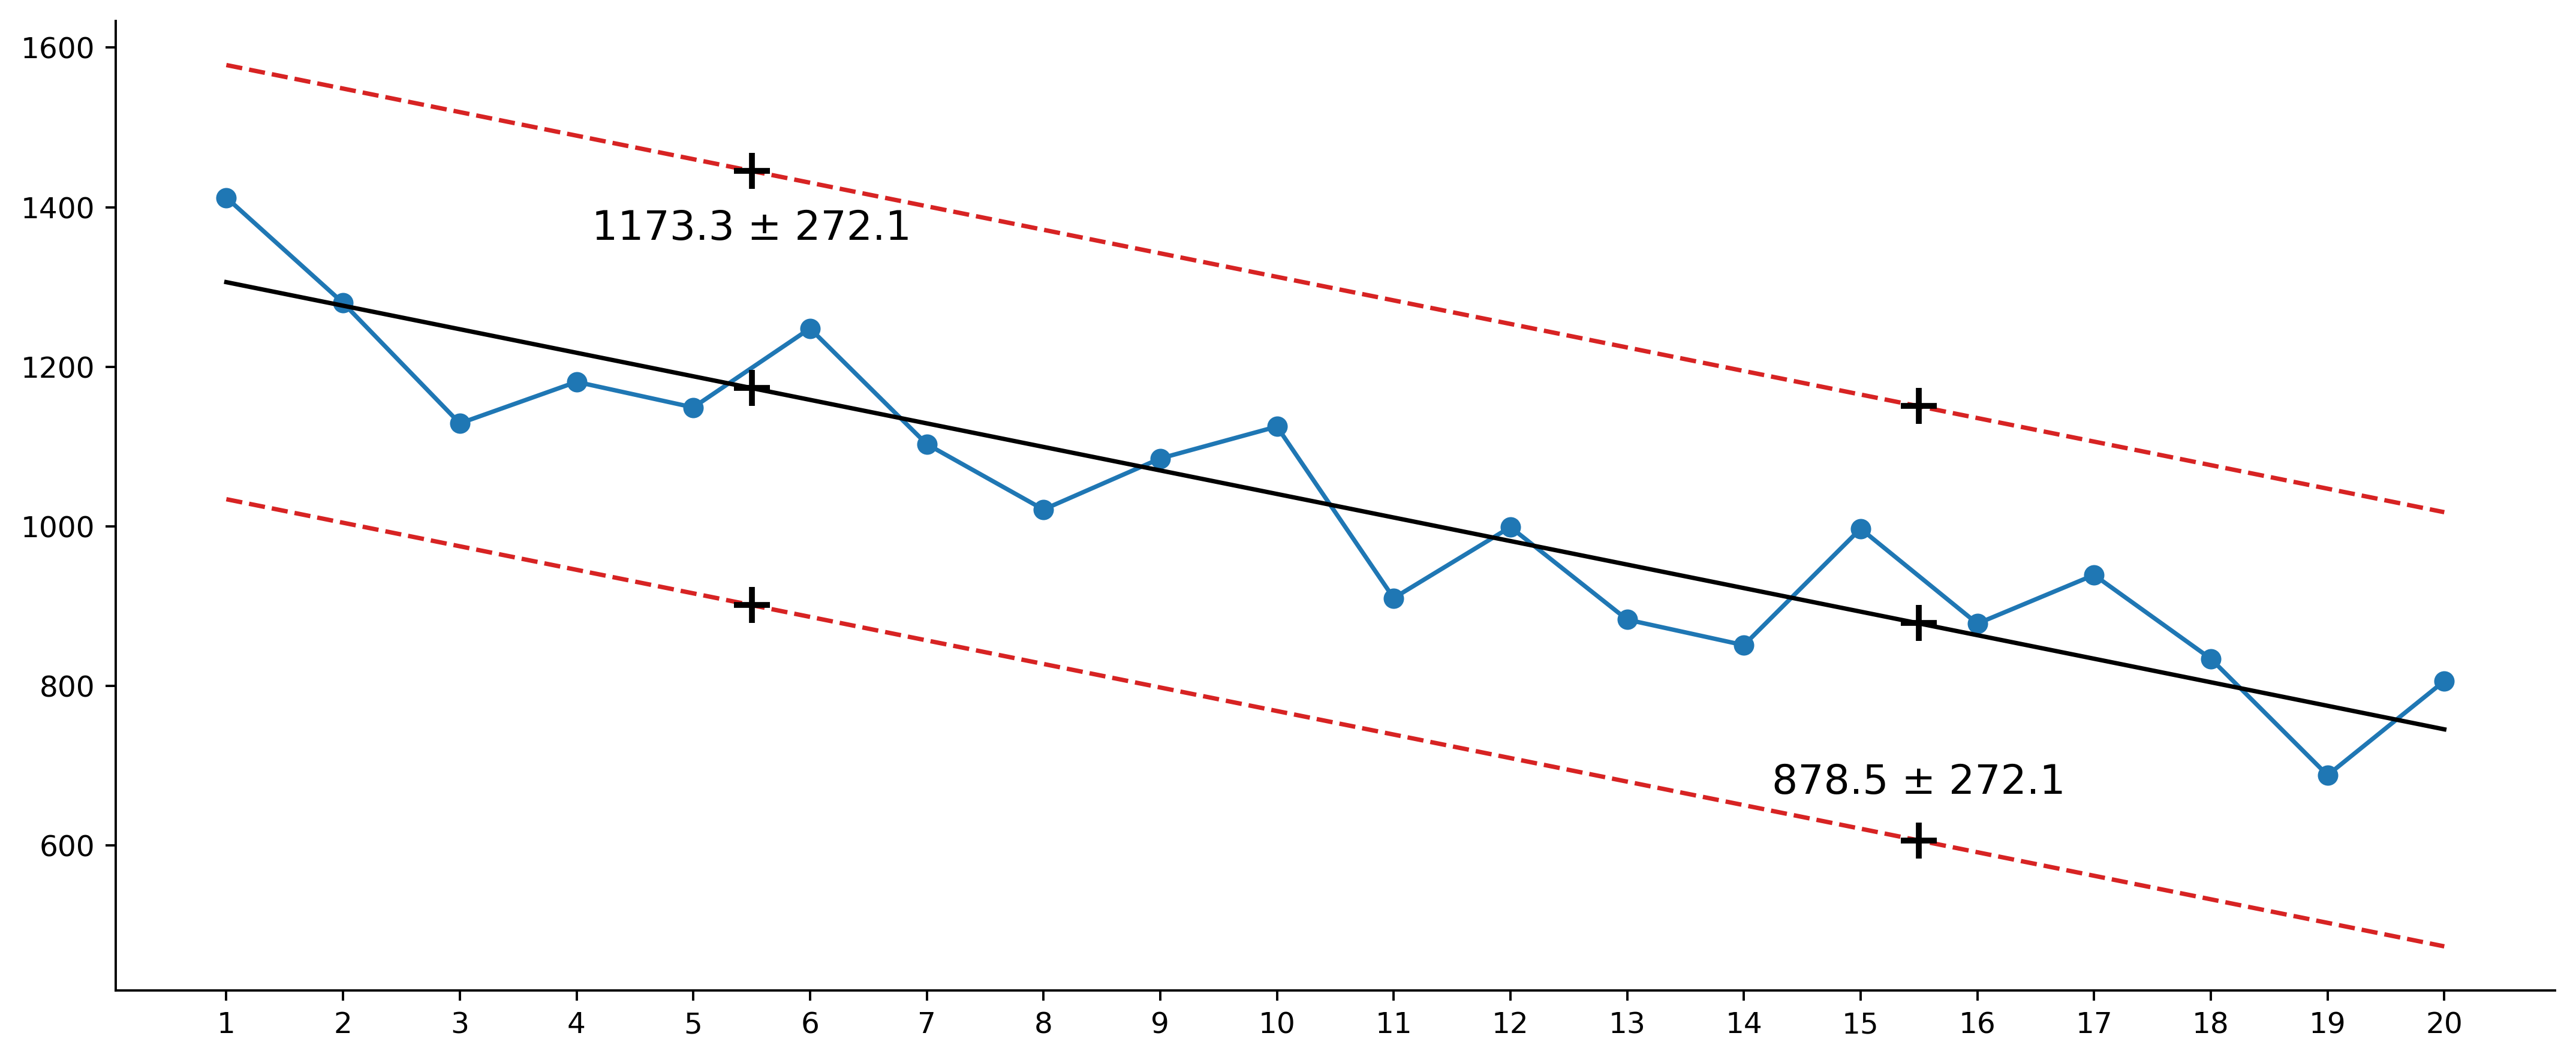

In [19]:
region_B_results = trend_xchart(
    region_B, 
    'Sales ($)', 
    'Quarter', show_mean_markers=True,
    config=config
)

## Trended X chart of Region D sales

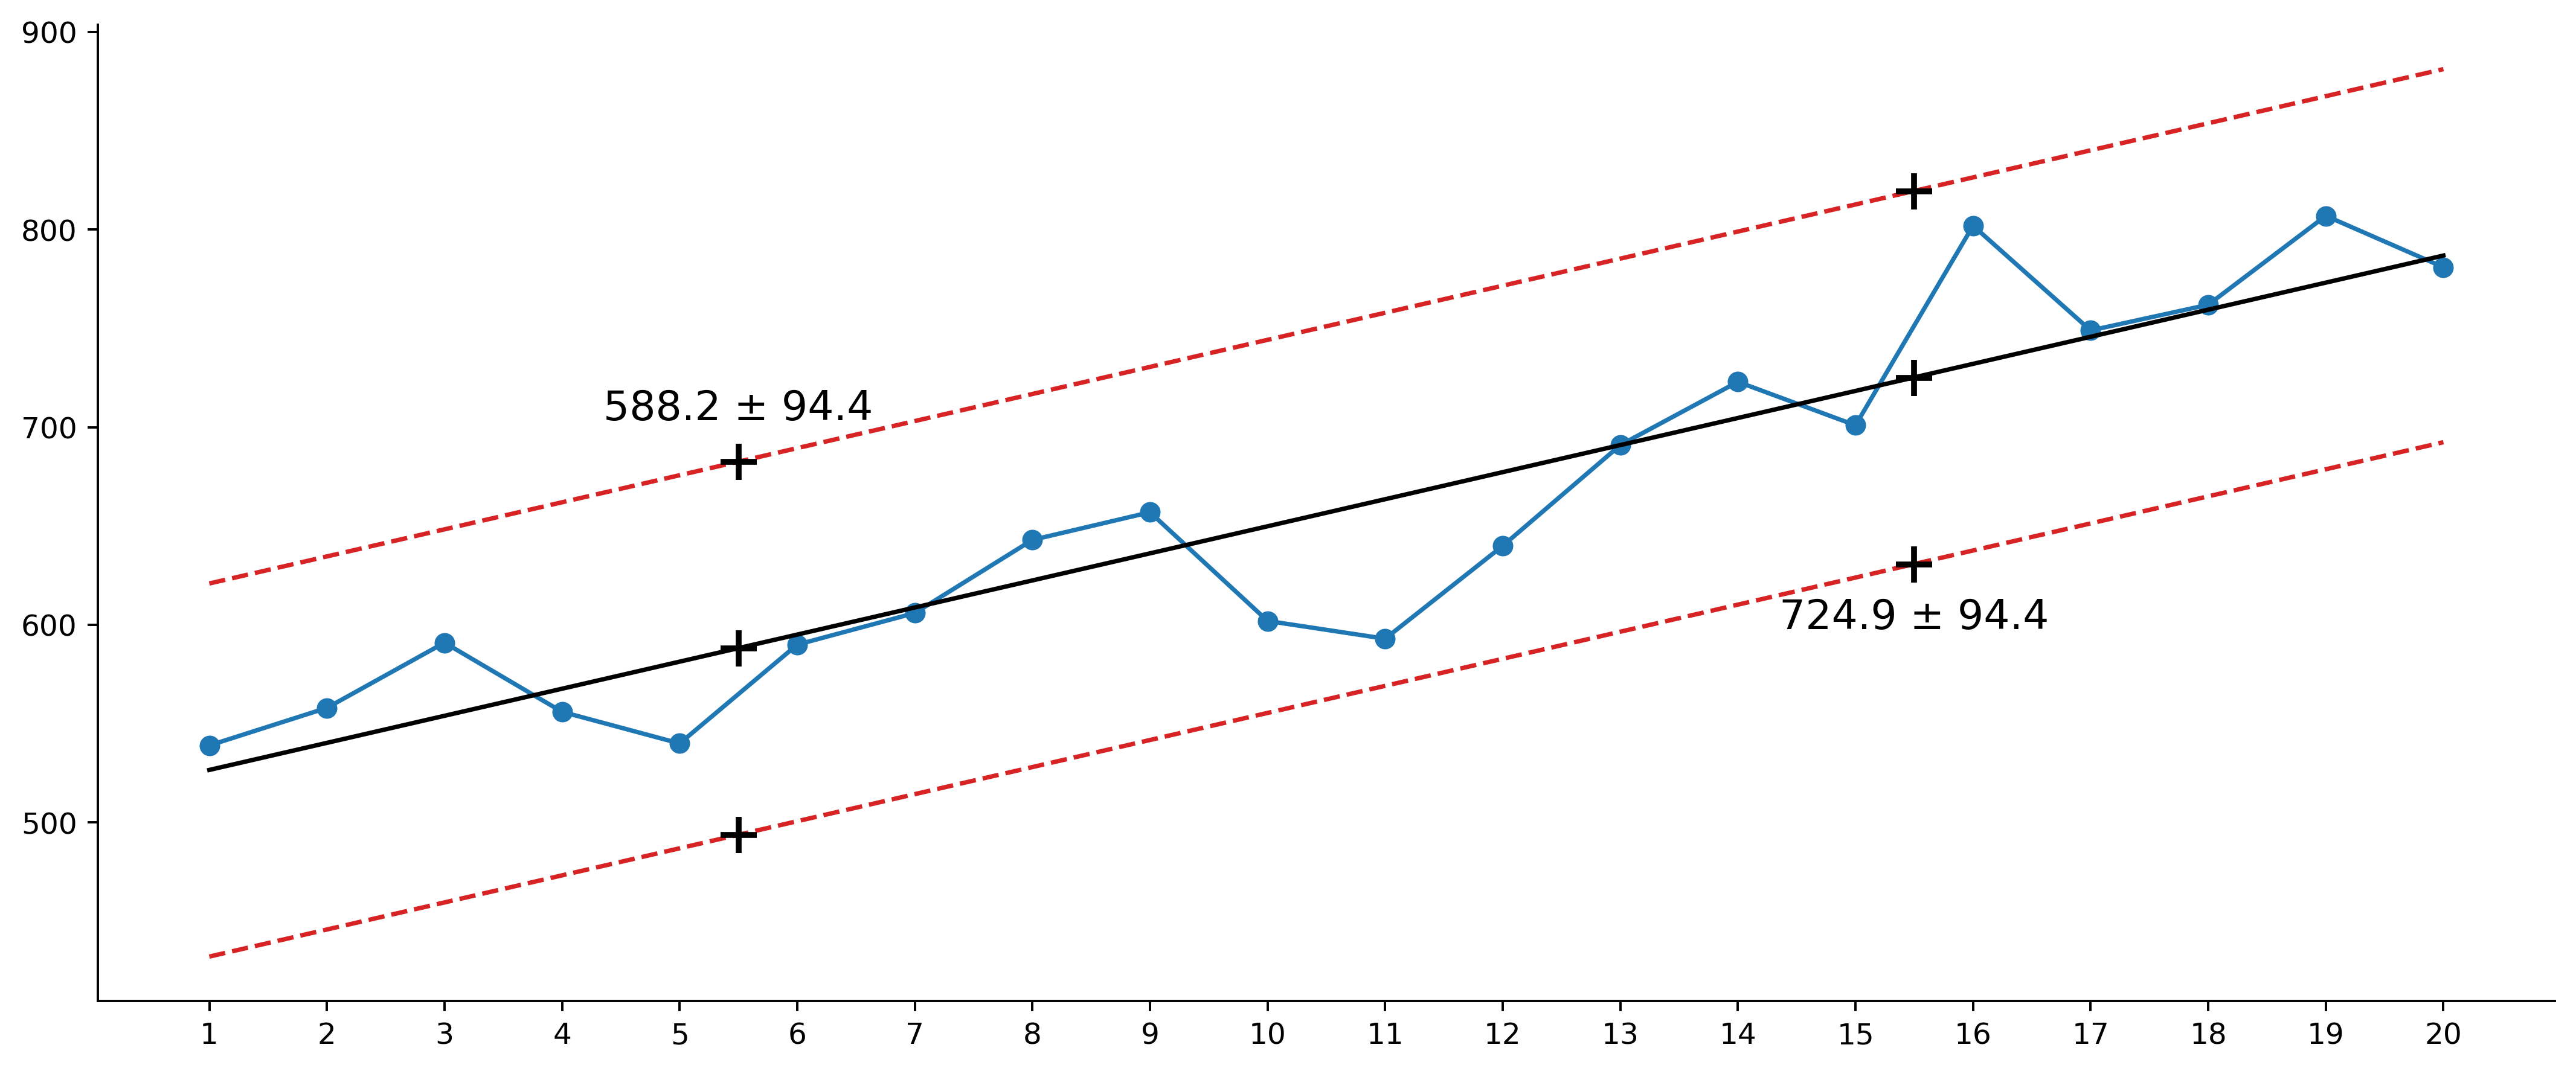

In [20]:
region_D_results = trend_xchart(
    region_D, 
    'Sales ($)', 
    'Quarter', show_mean_markers=True,
    config=config
)

## Trended X chart for Region F

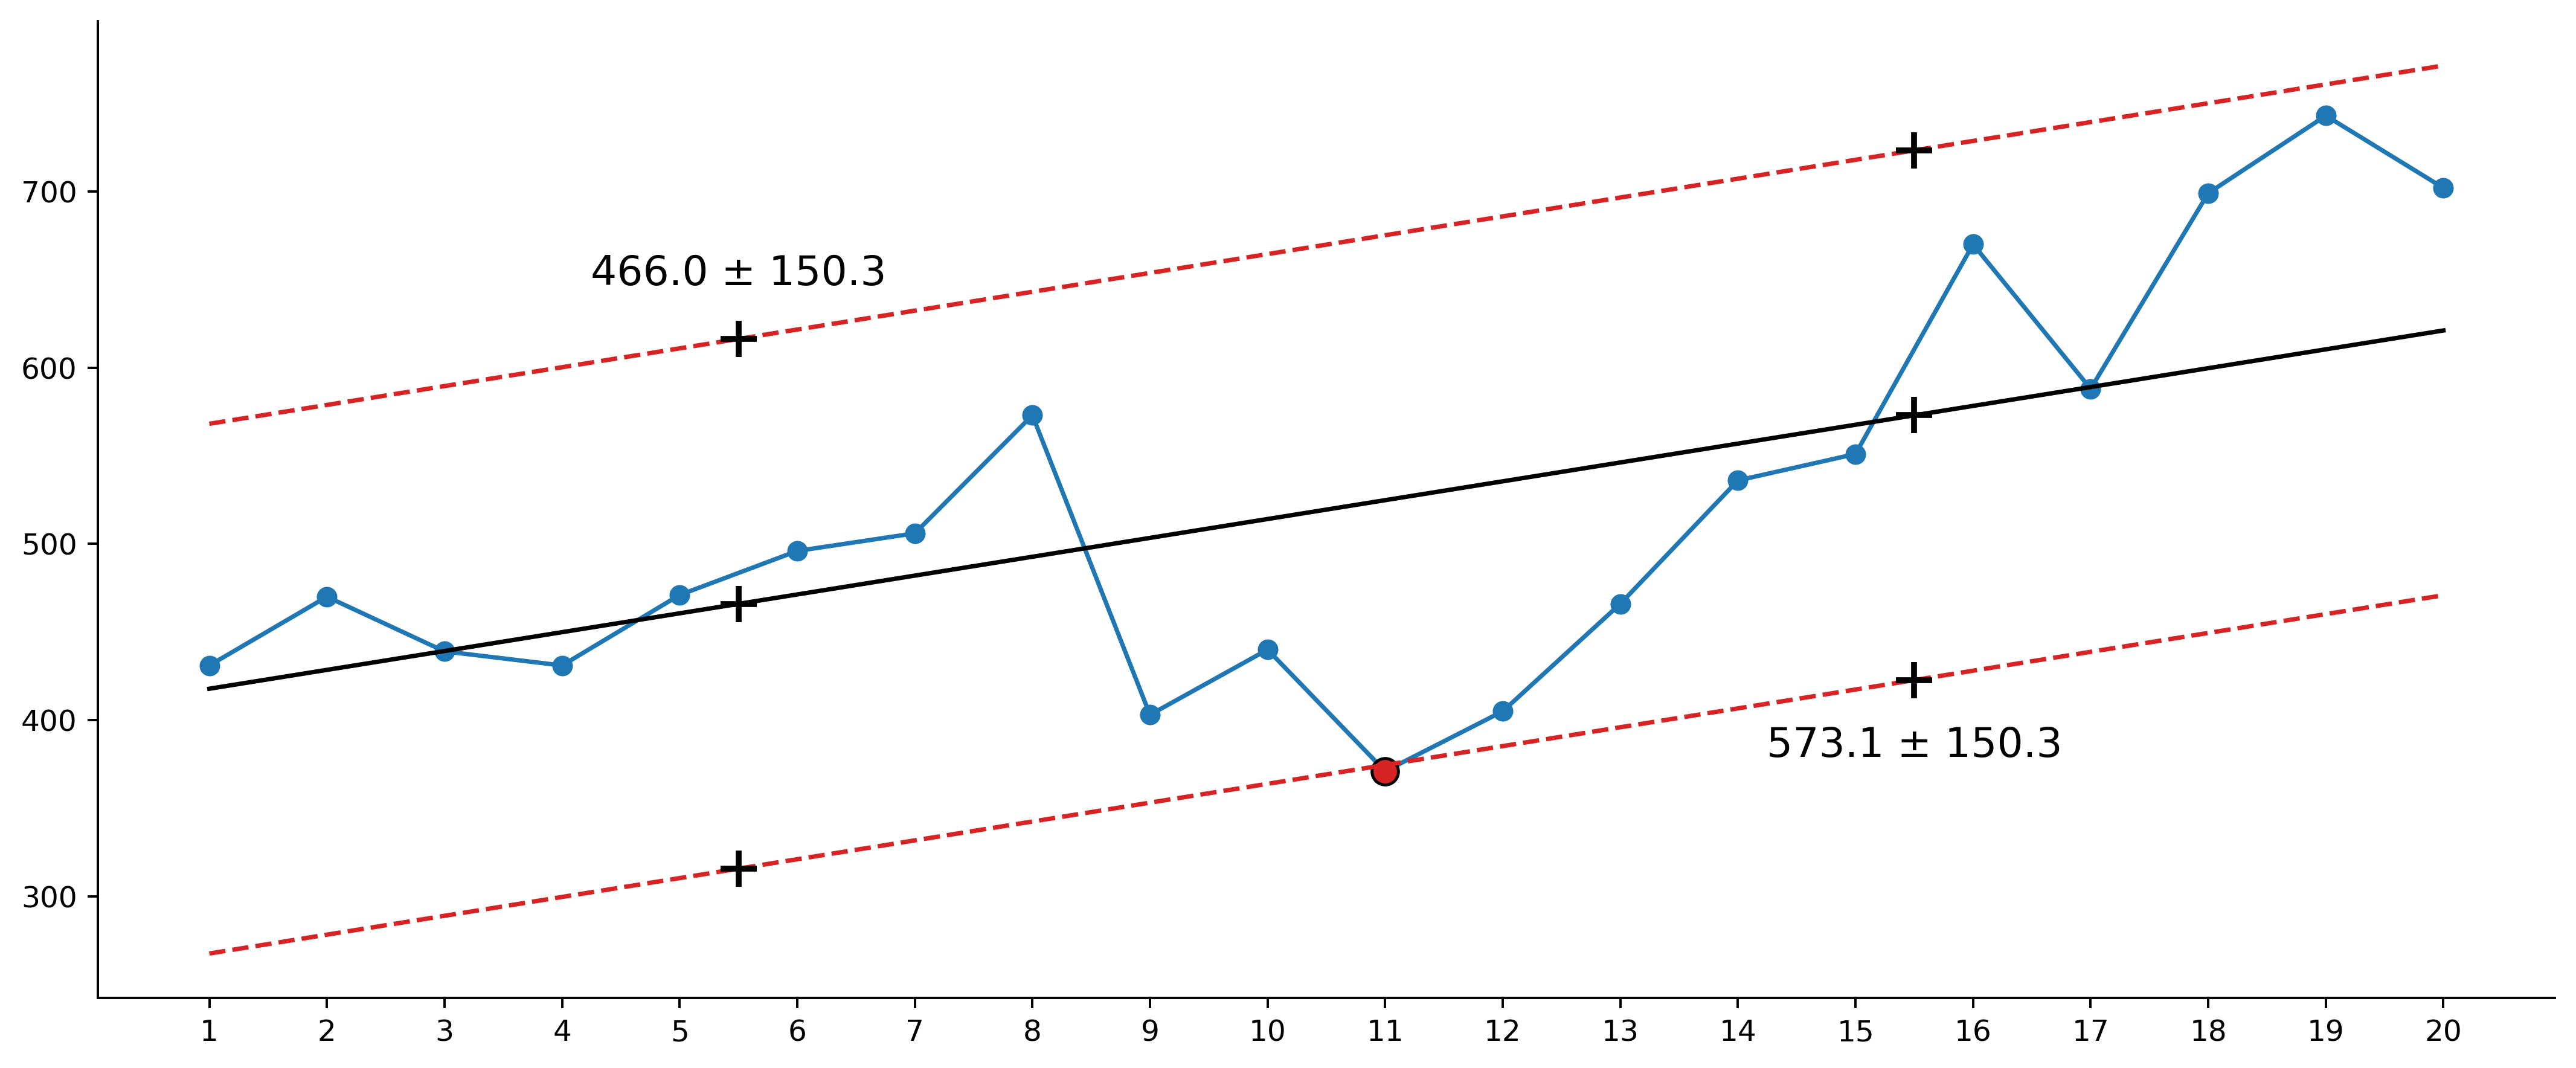

In [14]:
region_F_results = trend_xchart(
    region_F, 
    'Sales ($)', 
    'Quarter', show_mean_markers=True,
    config=config
)